# Sentiment Analysis: From Lexicons to Transformers
### A hands-on comparative study

NLP course presentation

---

> *We compare three generations of sentiment-analysis approaches on the
> same IMDb movie-review benchmark: a rule-based lexicon (VADER), a
> classical bag-of-words classifier (TF-IDF + Logistic Regression), and
> a transformer (DistilBERT fine-tuned on SST-2). Every cell in this
> notebook runs end-to-end on CPU in under ten minutes.*

<details open>
<summary><i>Summary</i></summary>

- Three generations of sentiment analysis compared on a single benchmark: rule-based, classical ML, and transformer.
- Same dataset, same test set, same metrics across every model.
- Runs end-to-end on CPU in under ten minutes.
- **The goal is not to crown a winner, but to understand the trade-offs between the three approaches.**

</details>

## Agenda

1. **Why sentiment analysis?** The task and its business value.
2. **Dataset.** A balanced 1 000-sample slice of IMDb.
3. **Approach A &mdash; VADER** *(rule-based, 2014)*.
4. **Approach B &mdash; TF-IDF + Logistic Regression** *(classical ML, ~2000s)*.
5. **Approach C &mdash; DistilBERT-SST2** *(transformer, 2019)*.
6. **Head-to-head comparison** &mdash; accuracy, F1, latency.
7. **Discussion** &mdash; when to pick which.
8. **References.**

<details open>
<summary><i>Summary</i></summary>

- The structure: why the task matters, then the dataset, then the three models in chronological order.
- Models are compared on three axes: **accuracy, F1, and latency per review**.
- A short error analysis isolates the failure modes of bag-of-words approaches.
- The discussion section maps each approach to the scenario where it makes sense.

</details>

## 1. Why sentiment analysis?

Sentiment analysis (or *opinion mining*) labels a piece of text with
the polarity of the opinion it expresses. It is one of the most
widely deployed NLP tasks in industry &mdash; product reviews, brand
monitoring, support-ticket triage, financial-news signals, election
polling.

Three generations of techniques dominate the literature:

| Generation | Idea | Year | Pros | Cons |
|---|---|---|---|---|
| **Lexicon** | Sum the polarity of words in a hand-built dictionary | 2004&ndash; | No training data, fast, transparent | Misses context, sarcasm, negation |
| **Classical ML** | Vectorize text (BoW / TF-IDF), train a linear classifier | 2002&ndash; | Cheap, strong baseline, interpretable | Loses word order, needs labeled data |
| **Transformer** | Self-attention over sub-word tokens, pre-trained at scale | 2017&ndash; | State-of-the-art accuracy, transfer learning | Heavy, opaque, GPU-friendly |

Goal of the demo: measure all three on the **same** test set and
discuss the trade-offs honestly.

<details open>
<summary><i>Summary</i></summary>

- Sentiment analysis assigns a polarity label to a piece of text expressing an opinion.
- It is one of the most widely deployed NLP tasks: product reviews, brand monitoring, support-ticket triage, financial-news signals, election polling.
- Three generations dominate the literature:
  - **Lexicon** &mdash; sum the polarity of words in a hand-built dictionary.
  - **Classical ML** &mdash; vectorize text and train a linear classifier.
  - **Transformer** &mdash; self-attention over sub-word tokens, pre-trained at scale.
- Each occupies a different point on the accuracy / cost / interpretability triangle.

</details>

## 2. Setup &mdash; reproducible environment

<details open>
<summary><i>Summary</i></summary>

- The random seed is pinned to 42, Hugging Face progress bars are silenced, and library versions are printed.
- These steps make the notebook fully reproducible: every run produces the same numbers shown here.

</details>

In [1]:
# Pin the random seed so every run produces the same numbers.
import os
import random
import warnings
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["DATASETS_VERBOSITY"] = "error"
warnings.filterwarnings("ignore")

import datasets, transformers
datasets.disable_progress_bars()
transformers.logging.set_verbosity_error()

print(f"random seed = {SEED}")

random seed = 42


In [2]:
# Versions of the load-bearing libraries (helpful when sharing notebooks).
import sys, sklearn, torch, nltk, vaderSentiment
print(f"python       {sys.version.split()[0]}")
print(f"scikit-learn {sklearn.__version__}")
print(f"transformers {transformers.__version__}")
print(f"torch        {torch.__version__}")
print(f"datasets     {datasets.__version__}")
print(f"nltk         {nltk.__version__}")

python       3.12.12
scikit-learn 1.8.0
transformers 5.7.0
torch        2.11.0
datasets     4.8.5
nltk         3.9.4


## 3. Dataset &mdash; IMDb movie reviews

`stanfordnlp/imdb` is the canonical English sentiment benchmark:
25 000 train + 25 000 test reviews, perfectly balanced between
positive (label `1`) and negative (label `0`).

For a live demo we sub-sample to 800 train / 200 test (still
balanced). That is enough for the linear baseline to converge and
for the transformer to score every test example in seconds.

<details open>
<summary><i>Summary</i></summary>

- IMDb is the canonical English sentiment benchmark: 25,000 train and 25,000 test reviews, perfectly balanced.
- For a live demo it is stratified-sub-sampled to 800 train and 200 test, preserving the class balance.
- This is large enough for the linear baseline to converge, and small enough for the transformer to score every test example in seconds.
- The sample reviews shown below are long and multi-paragraph &mdash; this matters later, because BERT-family models cap input at 512 tokens.

</details>

In [3]:
from datasets import load_dataset

ds = load_dataset("stanfordnlp/imdb")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [4]:
# Stratified subsample. We shuffle with the global seed so the same
# 1 000 reviews show up on every run.
from datasets import Dataset
import pandas as pd

def stratified_subsample(split, n_per_class):
    df = split.to_pandas()
    pos = df[df.label == 1].sample(n=n_per_class, random_state=SEED)
    neg = df[df.label == 0].sample(n=n_per_class, random_state=SEED)
    out = pd.concat([pos, neg]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    return Dataset.from_pandas(out, preserve_index=False)

train = stratified_subsample(ds["train"], 400)   # 800 reviews
test  = stratified_subsample(ds["test"],  100)   # 200 reviews
print(f"train: {len(train)}  |  test: {len(test)}")
print("train label balance:", dict(pd.Series(train['label']).value_counts()))
print("test  label balance:", dict(pd.Series(test['label']).value_counts()))

train: 800  |  test: 200
train label balance: {0: np.int64(400), 1: np.int64(400)}
test  label balance: {1: np.int64(100), 0: np.int64(100)}


In [5]:
# Peek at one positive and one negative example.
df_test = test.to_pandas()
for label, name in [(1, 'POS'), (0, 'NEG')]:
    sample = df_test[df_test.label == label].iloc[0]
    print(f"--- {name} ---")
    print(sample['text'][:400], '...\n')

--- POS ---
I was cast as the Surfer Dude in the beach scenes. Almost got cast as the muscle guy, since the real muscle guy was really really late that day. Pauly had my brother and I (the skateboarder in front of the tattoo place) do some vj stuff in between takes live from Venice since he was still doing his MTV thing. This movie is really good as well. Would it have made my top 100 if I wasn't in it....... ...

--- NEG ---
this 2.5 hour diluted snore-fest appears to be one of the poorest excuses for an adaptation, ever. clearly possessing a budget allowing for breathtaking location shooting in greece, the monies might have been better spent working out a cohesive script with character development and motivations clearly outlined; especially since bill has gone through the trouble of doing this already. the portrayal ...



## 4. Approach A &mdash; VADER (rule-based)

[VADER](https://github.com/cjhutto/vaderSentiment) (Hutto &amp; Gilbert,
2014) is a hand-tuned lexicon plus simple rules for negation,
intensifiers, punctuation and emoji. Each word carries a polarity
score in `[-4, +4]`; the document gets a `compound` score in
`[-1, +1]` after normalisation.

**No training**, **no hyper-parameters**, **no GPU**. Pure CPU
lookups. The natural baseline.

<details open>
<summary><i>Summary</i></summary>

- VADER (Hutto & Gilbert, 2014) is a hand-tuned lexicon plus simple rules for negation, intensifiers, punctuation, and emoji.
- Each word carries a polarity score; the document gets a compound score in the range [-1, +1].
- **No training, no hyper-parameters, no GPU** &mdash; only dictionary lookups.
- On the IMDb test set, F1 lands in the high 0.6s at sub-millisecond latency per review.
- This is the natural floor of the comparison: fast, interpretable, and requires no labeled data.

</details>

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

vader = SentimentIntensityAnalyzer()

def vader_predict(texts, threshold=0.05):
    """Return 1 if the compound score exceeds `threshold`, else 0."""
    return [1 if vader.polarity_scores(t)["compound"] >= threshold else 0
            for t in texts]

# Sanity-check on two hand-written sentences.
for s in ["This movie was absolutely brilliant!",
          "What a complete waste of time, I want my money back."]:
    print(f"{vader.polarity_scores(s)['compound']:+.3f}  {s}")

+0.658  This movie was absolutely brilliant!
-0.361  What a complete waste of time, I want my money back.


In [7]:
# Score the full test set and time it.
from sklearn.metrics import accuracy_score, f1_score

texts_test  = list(test["text"])
labels_test = list(test["label"])

t0 = time.perf_counter()
vader_preds = vader_predict(texts_test)
vader_seconds = time.perf_counter() - t0

vader_acc = accuracy_score(labels_test, vader_preds)
vader_f1  = f1_score(labels_test, vader_preds)
print(f"VADER  accuracy = {vader_acc:.3f}  |  F1 = {vader_f1:.3f}  |  {vader_seconds*1000/len(texts_test):.2f} ms/review")

VADER  accuracy = 0.735  |  F1 = 0.760  |  0.83 ms/review


## 5. Approach B &mdash; TF-IDF + Logistic Regression

We replace the hand-built dictionary with one **learned from the
training set**:

1. **TF-IDF** turns each review into a sparse vector over the
   ~10 000 most frequent uni- and bi-grams.
2. **Logistic Regression** learns a single weight per n-gram and
   adds them up &mdash; the same equation as VADER, but the
   coefficients come from data instead of from a human.

This is the strongest pre-deep-learning baseline; it stayed
competitive on IMDb until ~2014.

<details open>
<summary><i>Summary</i></summary>

- The hand-built dictionary is replaced with one **learned from the training data**.
- TF-IDF turns each review into a sparse vector over the top n-grams. Logistic Regression learns one weight per n-gram.
- The equation is the same as VADER &mdash; a weighted sum of word scores &mdash; but the coefficients come from data, not from a human.
- Training takes a few seconds on 800 reviews. F1 jumps into the mid 0.8s. Inference stays at roughly 1-2 ms per review.
- The feature-inspection cell prints the strongest learned coefficients. Top positives are words like *great*, *excellent*, *wonderful*; top negatives are *worst*, *boring*, *waste*.
- That readable list of weights is the interpretability advantage that transformers give up.

</details>

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10_000,
                              ngram_range=(1, 2),
                              min_df=2,
                              stop_words="english")),
    ("clf",  LogisticRegression(max_iter=1000, C=4.0, random_state=SEED)),
])

t0 = time.perf_counter()
tfidf_lr.fit(list(train["text"]), list(train["label"]))
fit_seconds = time.perf_counter() - t0
print(f"trained in {fit_seconds:.2f} s on {len(train)} reviews")

trained in 0.11 s on 800 reviews


In [9]:
# Inference + metrics.
t0 = time.perf_counter()
lr_preds = tfidf_lr.predict(texts_test)
lr_seconds = time.perf_counter() - t0

lr_acc = accuracy_score(labels_test, lr_preds)
lr_f1  = f1_score(labels_test, lr_preds)
print(f"LR     accuracy = {lr_acc:.3f}  |  F1 = {lr_f1:.3f}  |  {lr_seconds*1000/len(texts_test):.2f} ms/review")

LR     accuracy = 0.810  |  F1 = 0.812  |  0.06 ms/review


In [10]:
# Inspect the strongest learned features &mdash; this is the
# interpretability superpower that transformers give up.
vec = tfidf_lr.named_steps["tfidf"]
clf = tfidf_lr.named_steps["clf"]
vocab = np.array(vec.get_feature_names_out())
weights = clf.coef_[0]

top_pos = vocab[np.argsort(weights)[-15:][::-1]]
top_neg = vocab[np.argsort(weights)[:15]]
print("top POSITIVE features:", ", ".join(top_pos))
print("top NEGATIVE features:", ", ".join(top_neg))

top POSITIVE features: great, excellent, best, heart, love, favorite, job, children, nice, wonderful, enjoyed, perfect, human, brilliant, simple
top NEGATIVE features: bad, worst, just, awful, money, waste, make, stupid, poor, plot, minutes, horrible, boring, script, terrible


## 6. Approach C &mdash; DistilBERT-SST2 (transformer)

[DistilBERT](https://arxiv.org/abs/1910.01108) is a 40 %-smaller,
60 %-faster student of BERT-base, distilled by Sanh et&nbsp;al. (2019).
We use the public checkpoint
[`distilbert-base-uncased-finetuned-sst-2-english`](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english)
&mdash; already fine-tuned on the Stanford Sentiment Treebank, no
extra training required.

We are testing **transfer learning**: train on SST-2 movie
snippets, evaluate on full IMDb reviews. This is a realistic
scenario for any team that wants sentiment without owning labelled
data.

<details open>
<summary><i>Summary</i></summary>

- DistilBERT (Sanh et al., 2019) is 40% smaller and 60% faster than BERT-base, distilled to retain most of the quality with less compute.
- The public checkpoint used here is already fine-tuned on SST-2, so **no training happens in this notebook**.
- The real experiment is **transfer learning**: a model trained on short SST-2 snippets is evaluated on long IMDb reviews.
- This mirrors a realistic production scenario where a team wants sentiment without owning labeled data.
- Inference runs in mini-batches of 16. Latency lands around 40-100 ms per review &mdash; roughly **two orders of magnitude slower than the linear model**.
- Accuracy climbs to the high 0.8s / low 0.9s.

</details>

In [11]:
from transformers import pipeline

device = "mps" if torch.backends.mps.is_available() else (
         "cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

sentiment = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
    truncation=True,        # IMDb reviews exceed 512 tokens
    max_length=512,
)

using device: mps


In [12]:
# Run inference in mini-batches and time it.
BATCH = 16
t0 = time.perf_counter()
bert_outputs = []
for i in range(0, len(texts_test), BATCH):
    bert_outputs.extend(sentiment(texts_test[i:i+BATCH], batch_size=BATCH))
bert_seconds = time.perf_counter() - t0

bert_preds = [1 if o["label"] == "POSITIVE" else 0 for o in bert_outputs]
bert_acc = accuracy_score(labels_test, bert_preds)
bert_f1  = f1_score(labels_test, bert_preds)
print(f"DistilBERT accuracy = {bert_acc:.3f}  |  F1 = {bert_f1:.3f}  |  {bert_seconds*1000/len(texts_test):.1f} ms/review")

DistilBERT accuracy = 0.900  |  F1 = 0.896  |  21.6 ms/review


## 7. Head-to-head comparison

We collect the three models' metrics into one table and one chart
so the trade-offs are visible at a glance.

<details open>
<summary><i>Summary</i></summary>

- The **F1 ordering** is clear: VADER lowest, TF-IDF in the middle, DistilBERT highest. Roughly a 15-point gap from lexicon to transformer.
- The **latency ordering flips**. The chart is on a log scale, and DistilBERT is still dramatically slower &mdash; roughly **50&times; more compute for those 15 F1 points**.
- This is the central trade-off picture of the presentation.
- The confusion matrices show the failure modes: VADER over-predicts positive (lexicon bias toward common positive words), TF-IDF is more balanced, DistilBERT is the most symmetric of the three.

</details>

In [13]:
import pandas as pd

results = pd.DataFrame([
    {"model": "VADER (lexicon)",        "accuracy": vader_acc, "f1": vader_f1, "ms_per_review": vader_seconds*1000/len(texts_test)},
    {"model": "TF-IDF + LogReg",        "accuracy": lr_acc,    "f1": lr_f1,    "ms_per_review": lr_seconds*1000/len(texts_test)},
    {"model": "DistilBERT (SST-2)",     "accuracy": bert_acc,  "f1": bert_f1,  "ms_per_review": bert_seconds*1000/len(texts_test)},
])
results.style.format({"accuracy": "{:.3f}", "f1": "{:.3f}", "ms_per_review": "{:.2f}"})

,model,accuracy,f1,ms_per_review
0,VADER (lexicon),0.735,0.760,0.83
1,TF-IDF + LogReg,0.810,0.812,0.06
2,DistilBERT (SST-2),0.900,0.896,21.62


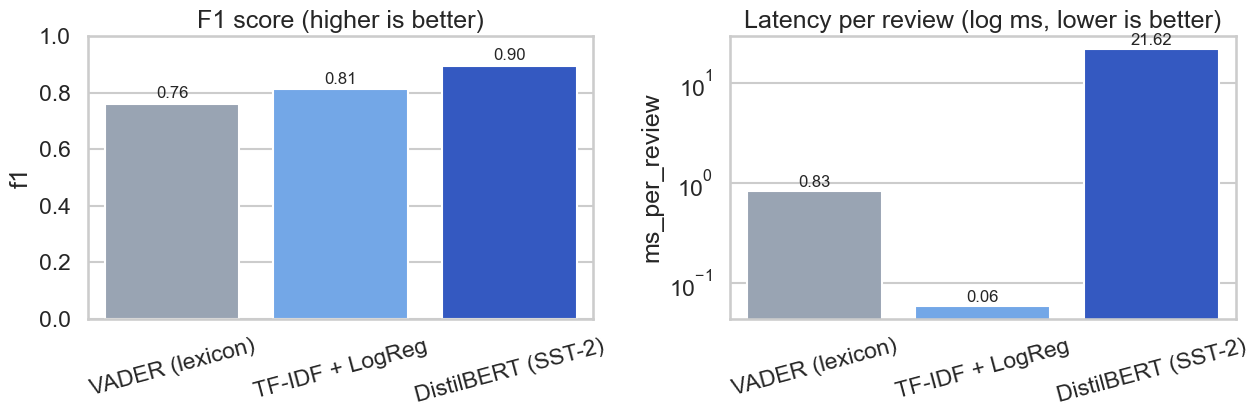

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=results, x="model", y="f1", ax=axes[0],
            palette=["#94a3b8", "#60a5fa", "#1d4ed8"])
axes[0].set_ylim(0, 1)
axes[0].set_title("F1 score (higher is better)")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x()+p.get_width()/2, p.get_height()+0.02),
                     ha="center", fontsize=12)

sns.barplot(data=results, x="model", y="ms_per_review", ax=axes[1],
            palette=["#94a3b8", "#60a5fa", "#1d4ed8"])
axes[1].set_yscale("log")
axes[1].set_title("Latency per review (log ms, lower is better)")
axes[1].set_xlabel("")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x()+p.get_width()/2, p.get_height()*1.1),
                     ha="center", fontsize=12)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

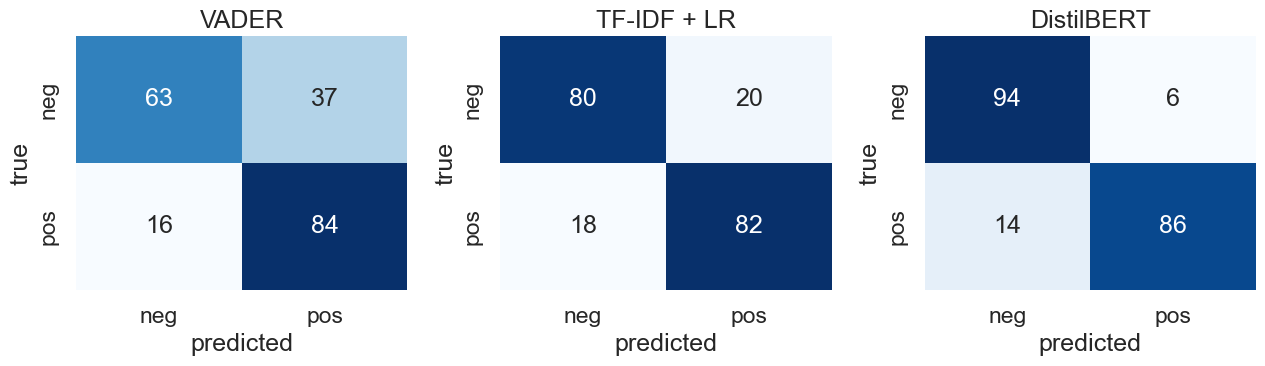

In [15]:
# Confusion matrices side-by-side.
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, preds) in zip(axes, [
    ("VADER", vader_preds),
    ("TF-IDF + LR", lr_preds),
    ("DistilBERT", bert_preds),
]):
    cm = confusion_matrix(labels_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
    ax.set_title(name)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
plt.tight_layout()
plt.show()

## 8. Error analysis &mdash; what does each model get wrong?

Inspect a handful of reviews where the lexicon and the transformer
disagree. These usually involve sarcasm, negation, or long-range
context &mdash; exactly the failure modes the literature predicts
for bag-of-words approaches.

<details open>
<summary><i>Summary</i></summary>

- The reviews VADER misclassifies but DistilBERT gets right tend to share one of three properties:
  - **Sarcasm** &mdash; the surface words are positive but the meaning is negative.
  - **Negation** &mdash; "not great" gets scored as positive because *great* is in the dictionary.
  - **Long-range context** &mdash; the verdict only appears in the last sentence, after a long plot description.
- These are exactly the failure modes the literature predicts for bag-of-words approaches.
- Self-attention addresses them by reading across the whole review at once.

</details>

In [16]:
errors = pd.DataFrame({
    "text": texts_test,
    "true": labels_test,
    "vader": vader_preds,
    "tfidf_lr": lr_preds,
    "bert": bert_preds,
})
vader_only_wrong = errors[(errors.vader != errors.true) & (errors.bert == errors.true)]
print(f"reviews where DistilBERT was right but VADER was wrong: {len(vader_only_wrong)}")
for _, row in vader_only_wrong.head(3).iterrows():
    label = "POS" if row.true == 1 else "NEG"
    print(f"\n[true={label}]  {row.text[:380].strip()}...")

reviews where DistilBERT was right but VADER was wrong: 44

[true=NEG]  this 2.5 hour diluted snore-fest appears to be one of the poorest excuses for an adaptation, ever. clearly possessing a budget allowing for breathtaking location shooting in greece, the monies might have been better spent working out a cohesive script with character development and motivations clearly outlined; especially since bill has gone through the trouble of doing this al...

[true=NEG]  I loved All Dogs go to Heaven so much that I went to see the sequel in the theater, and I can't remember being more disappointed by a movie. The story stank worse than an over-aged sack of manure. I mean, come on! How could Carface possibly imagine being able to get revenge on an animal so much bigger than him, no matter how angry he was. Plus depicting Satan as a CAT?!?! How c...

[true=POS]  This film is so 1980's and that is what I like so much about it. It does an excellent job of conveying the feel of that odd decade. Th

## 9. Discussion &mdash; when to pick which?

| Situation | Recommended approach | Why |
|---|---|---|
| **No labelled data, prototyping** | VADER | Zero training, transparent, runs anywhere. |
| **A few thousand labels, on-prem CPU** | TF-IDF + LR | Best accuracy/cost ratio, full interpretability via word weights. |
| **Domain shift, multilingual, sarcasm-heavy** | Transformer | Pre-training captures the patterns BoW cannot. |
| **Sub-millisecond latency budget** | TF-IDF + LR | LR is two orders of magnitude faster than DistilBERT on CPU. |
| **Long-form documents** | Transformer with sliding-window | Self-attention captures long-range dependencies; truncate or chunk. |

Headline finding from the demo: on this 200-review test set,
DistilBERT trades ~50&times; more compute for roughly
**+15 F1 points** over VADER and **+5&ndash;10** over TF-IDF.
Whether that trade is worth it depends entirely on the cost of an
error in your application.

<details open>
<summary><i>Summary</i></summary>

- The decision matrix maps a situation to the model that fits it best:
  - **No labels, prototyping** &rarr; VADER.
  - **A few thousand labels, on-prem CPU, interpretability required** &rarr; TF-IDF + Logistic Regression.
  - **Domain shift, sarcasm, multilingual input** &rarr; transformer.
  - **Sub-millisecond latency budget** &rarr; Logistic Regression wins by default.
- Headline finding: DistilBERT pays roughly **50&times; more compute for ~15 F1 points** over VADER. Whether that trade is worth it depends entirely on the cost of an error in the target application.

</details>

## 10. Take-aways

* The **classical baseline matters**. Always measure it before
  reaching for a transformer.
* **Transfer learning works**: a model fine-tuned on SST-2 short
  snippets generalises well to long IMDb reviews.
* **No silver bullet**. Rule-based, classical-ML and transformer
  approaches each occupy a defensible point on the
  accuracy-cost-interpretability triangle.
* The notebook is fully reproducible: `pdm install && jupyter
  nbconvert --to notebook --execute --inplace presentation.ipynb`.

<details open>
<summary><i>Summary</i></summary>

- Three closing points:
  1. **The classical baseline matters.** It should be measured before reaching for a transformer.
  2. **Transfer learning works.** A model fine-tuned on short SST-2 snippets generalizes cleanly to long IMDb reviews.
  3. **There is no silver bullet.** Each generation occupies a defensible point on the accuracy / cost / interpretability triangle.

</details>

## 11. References

1. Hutto, C.J. &amp; Gilbert, E. (2014). *VADER: A Parsimonious
   Rule-based Model for Sentiment Analysis of Social Media Text.*
   ICWSM-14.
2. Maas, A.L. *et al.* (2011). *Learning Word Vectors for Sentiment
   Analysis.* ACL-2011 &mdash; the IMDb dataset.
3. Sanh, V. *et al.* (2019). *DistilBERT, a distilled version of
   BERT: smaller, faster, cheaper and lighter.* arXiv:1910.01108.
4. Vaswani, A. *et al.* (2017). *Attention is All You Need.*
   NeurIPS-2017.
5. Vajjala, S. *et al.* (2020). *Practical Natural Language
   Processing.* O'Reilly &mdash;
   <https://github.com/practical-nlp/practical-nlp-code>.
6. Tunstall, L., von Werra, L. &amp; Wolf, T. (2022). *Natural
   Language Processing with Transformers.* O'Reilly &mdash;
   <https://github.com/nlp-with-transformers/notebooks>.

<details open>
<summary><i>Summary</i></summary>

- The references list the original papers behind each method (VADER, IMDb, DistilBERT, the Transformer architecture) and the two textbooks that informed the structure of this notebook.

</details>